
Initializing TensorFlow...
TensorFlow Version: 2.19.0
DEPLOYING PRODUCTION NEURAL NETWORK
WITH DATA LEAKAGE PREVENTION

LOADING DATA
Dataset shape: (283773, 113)
Removed 707 duplicate records

Original features: 112
Classes: [np.int64(1), np.int64(2), np.int64(3)]
Class distribution: {1: np.int64(160418), 2: np.int64(77939), 3: np.int64(44709)}
  Class 1: 160,418 samples (56.7%)
  Class 2: 77,939 samples (27.5%)
  Class 3: 44,709 samples (15.8%)

SPLITTING AND PREPROCESSING DATA
(Data leakage prevention: ✅ All preprocessing fitted on training data only)

Data splits (before preprocessing):
  Training set: (191068, 112)
  Validation set: (35384, 112)
  Testing set: (56614, 112)

Converting labels to 0-indexed...
Label mapping: {np.int64(1): 0, np.int64(2): 1, np.int64(3): 2}

TABULAR DATA PREPROCESSOR - FITTING ON TRAINING DATA
   Original features: 112
   Excluded 3 specified features: ['age', 'basic_age', 'basic_bmi']

   Removing highly correlated features (>0.95)...
   Removed 36 h

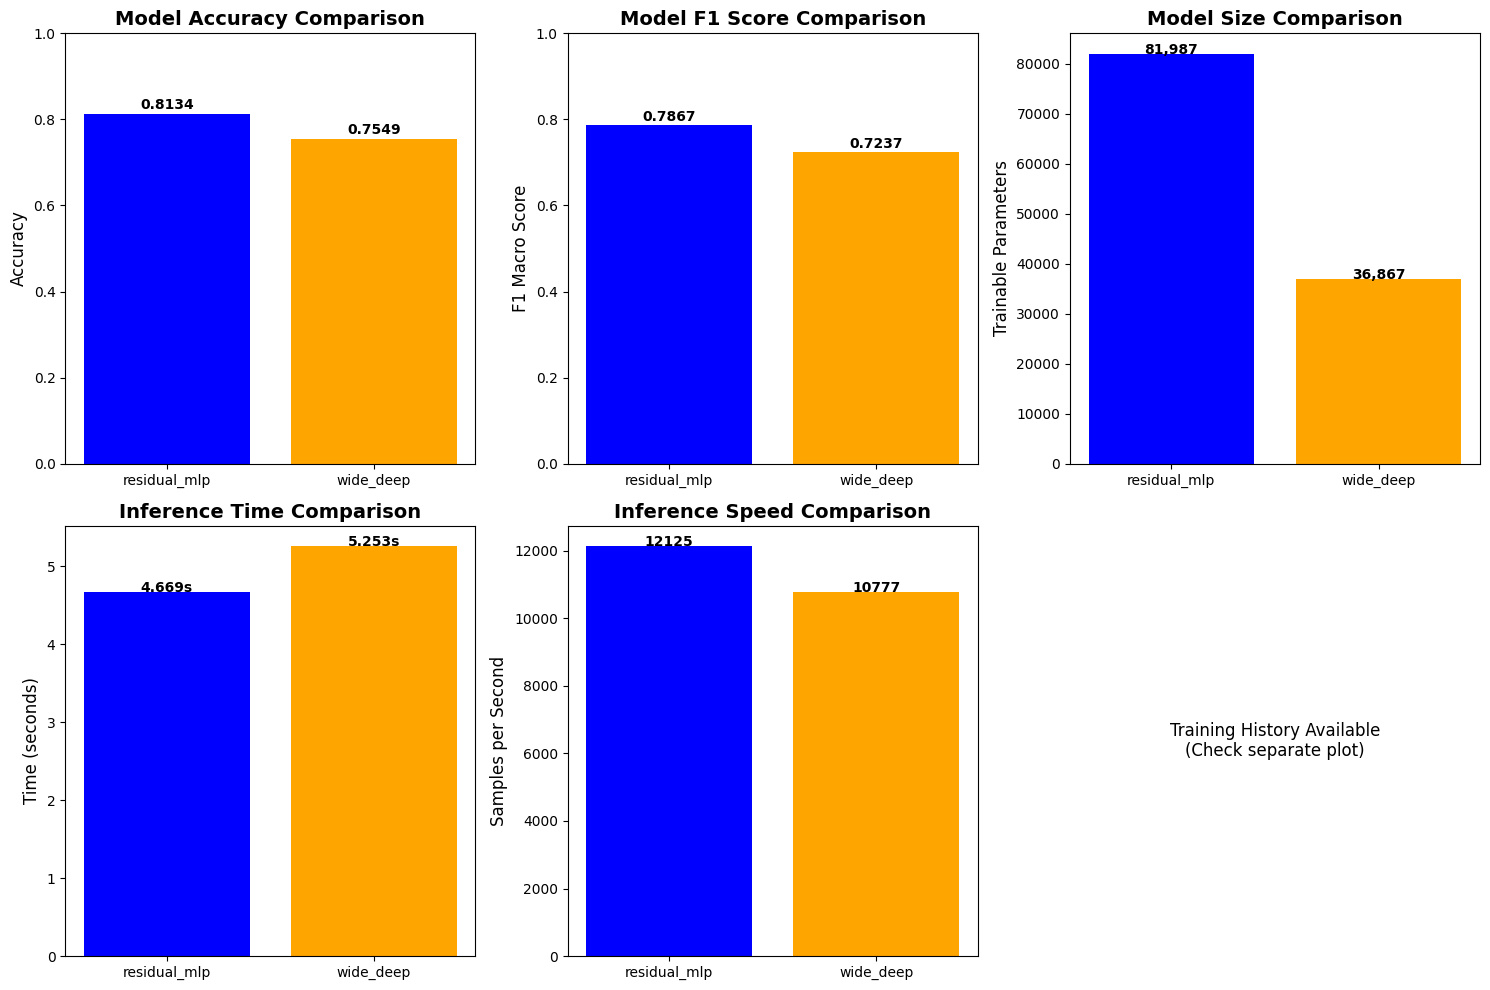


DETAILED REPORTS

DETAILED EVALUATION - RESIDUAL_MLP


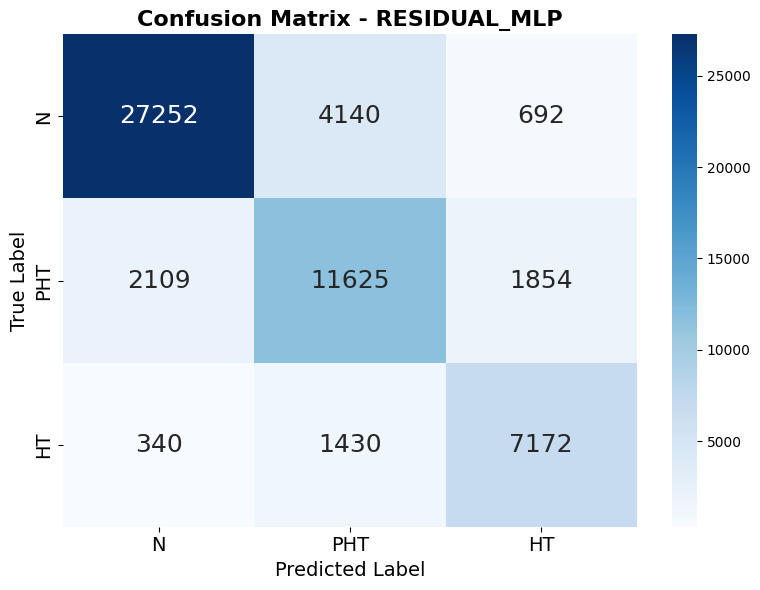


CLASSIFICATION REPORT - RESIDUAL_MLP

              precision    recall  f1-score   support

           1       0.92      0.85      0.88     32084
           2       0.68      0.75      0.71     15588
           3       0.74      0.80      0.77      8942

    accuracy                           0.81     56614
   macro avg       0.78      0.80      0.79     56614
weighted avg       0.82      0.81      0.82     56614


DETAILED EVALUATION - WIDE_DEEP


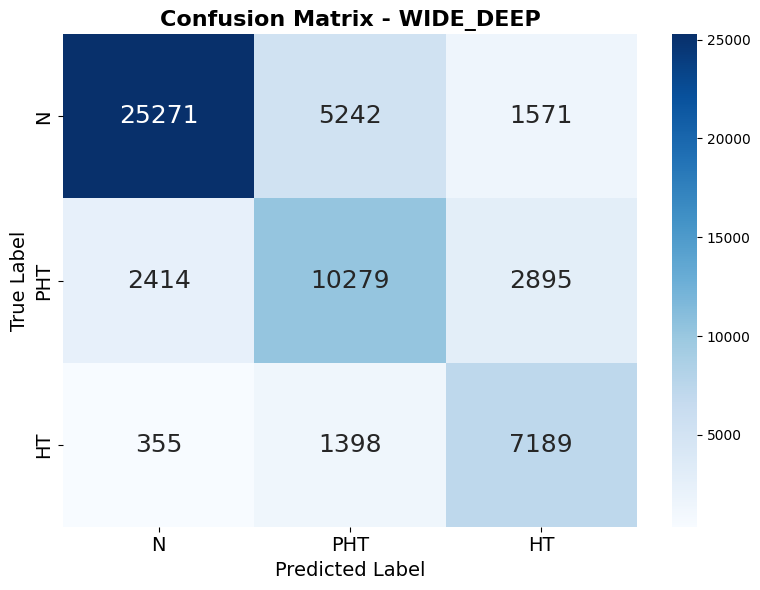


CLASSIFICATION REPORT - WIDE_DEEP

              precision    recall  f1-score   support

           1       0.90      0.79      0.84     32084
           2       0.61      0.66      0.63     15588
           3       0.62      0.80      0.70      8942

    accuracy                           0.75     56614
   macro avg       0.71      0.75      0.72     56614
weighted avg       0.78      0.75      0.76     56614


Saving pipeline to tabular_nn_pipeline/...
  ✓ Saved residual_mlp model
  ✓ Saved wide_deep model
  ✓ Saved preprocessor components
  ✓ Saved label encoder
Pipeline saved successfully to tabular_nn_pipeline/

TRAINING HISTORY


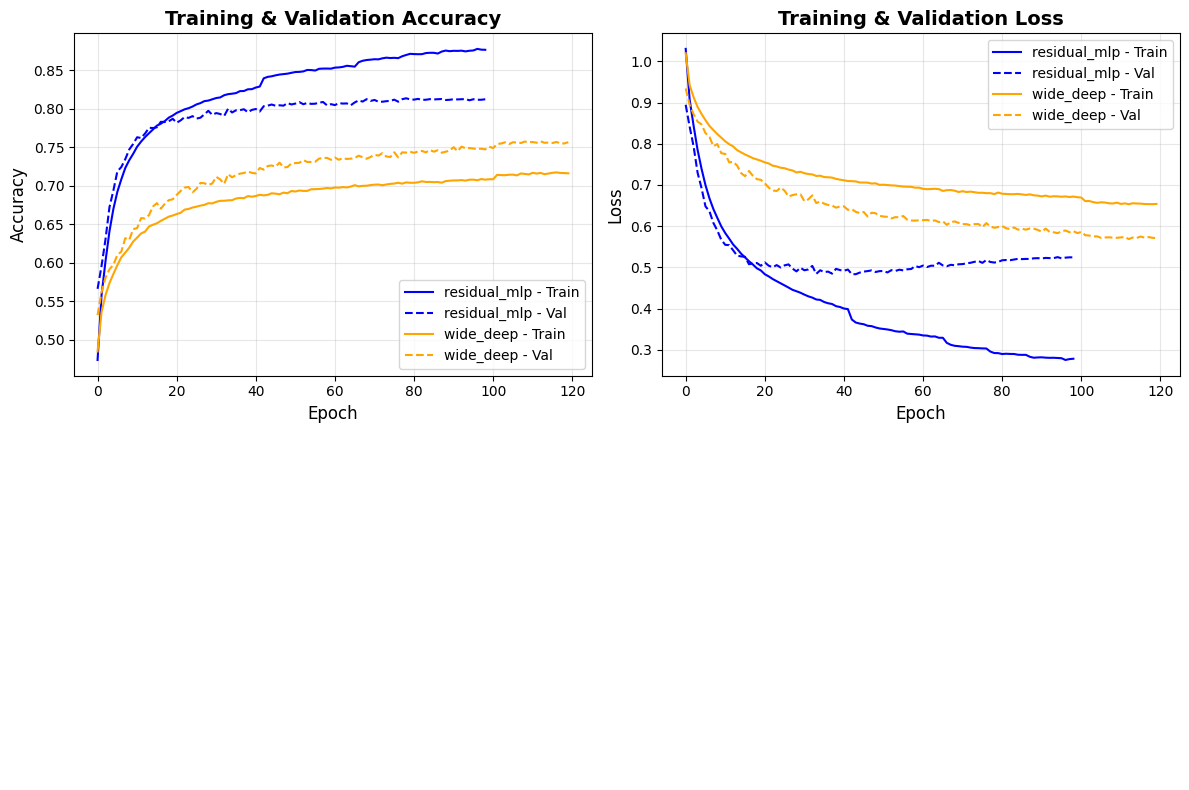


DEPLOYMENT COMPLETE!

Summary:
  Best Model: residual_mlp
  Best Accuracy: 0.8134
  Best F1 Macro: 0.7867
  Models saved to: tabular_nn_pipeline/
  Data leakage prevention: ✅ Implemented

PREDICTION API TEST

Loading pipeline from tabular_nn_pipeline/...
  ✓ Loaded wide_deep model
  ✓ Loaded residual_mlp model
  ✓ Loaded preprocessor components
  ✓ Loaded label encoder
  ✓ Loaded metadata
Pipeline loaded successfully from tabular_nn_pipeline/
Predictor loaded successfully!

Example usage:
  predictor = TabularNNPredictor('tabular_nn_pipeline')
  result = predictor.predict(X_new, model_name='residual_mlp')
  results, df = predictor.compare_predictions(X_new)


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight
from sklearn.base import BaseEstimator, TransformerMixin
import joblib
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import time
import os

warnings.filterwarnings('ignore')

# ==================== PREPROCESSOR CLASS ====================

class TabularDataPreprocessor:
    """Preprocessor for tabular data without data leakage"""

    def __init__(self, top_features=50, correlation_threshold=0.95, variance_threshold=0.01, exclude_features=None):
        self.top_features = top_features
        self.correlation_threshold = correlation_threshold
        self.variance_threshold = variance_threshold
        self.exclude_features = exclude_features if exclude_features is not None else []

        # Initialize attributes
        self.constant_cols_ = None
        self.correlated_cols_ = None
        self.imputer_ = None
        self.variance_selector_ = None
        self.feature_selector_ = None
        self.scaler_ = None
        self.selected_features_ = None
        self.excluded_features_ = None  # track features actually removed
        self.excluded_features_ = []

    def fit(self, X, y=None):
        """Fit preprocessor on training data only"""
        X = X.copy()

        print("\n" + "="*80)
        print("TABULAR DATA PREPROCESSOR - FITTING ON TRAINING DATA")
        print("="*80)

        print(f"   Original features: {X.shape[1]}")

        # 0. Exclude specified features
        if self.exclude_features:
            to_exclude = [col for col in self.exclude_features if col in X.columns]
            if to_exclude:
                X = X.drop(columns=to_exclude)
                self.excluded_features_ = to_exclude
                print(f"   Excluded {len(to_exclude)} specified features: {to_exclude}")

        # 1. Remove constant columns
        self.constant_cols_ = [col for col in X.columns if X[col].nunique() == 1]
        if self.constant_cols_:
            print(f"   Found {len(self.constant_cols_)} constant columns")
            X = X.drop(columns=self.constant_cols_)

        # 2. Handle missing values
        if X.isnull().sum().sum() > 0:
            self.imputer_ = SimpleImputer(strategy='median')
            X = pd.DataFrame(self.imputer_.fit_transform(X), columns=X.columns)
            print(f"   Imputed missing values with median")

        # 3. Remove highly correlated features
        print(f"\n   Removing highly correlated features (>0.95)...")
        if len(X.columns) > 50:
            # Calculate correlation matrix
            corr_matrix = X.corr().abs()
            upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
            self.correlated_cols_ = [column for column in upper.columns if any(upper[column] > self.correlation_threshold)]

            if self.correlated_cols_:
                X = X.drop(columns=self.correlated_cols_)
                print(f"   Removed {len(self.correlated_cols_)} highly correlated features")
                print(f"   Remaining features: {X.shape[1]}")

        # 4. Feature selection (only if y is provided)
        if y is not None and len(X.columns) > 0:
            # First remove low variance features
            self.variance_selector_ = VarianceThreshold(threshold=self.variance_threshold)
            X_var = self.variance_selector_.fit_transform(X)
            remaining_features = X.columns[self.variance_selector_.get_support()].tolist()
            X = pd.DataFrame(X_var, columns=remaining_features)
            print(f"   After variance threshold: {X.shape[1]} features")

            if X.shape[1] > self.top_features:
                # Then use SelectKBest
                self.feature_selector_ = SelectKBest(score_func=f_classif,
                                                    k=min(self.top_features, X.shape[1]))
                X_selected = self.feature_selector_.fit_transform(X, y)
                selected_indices = self.feature_selector_.get_support(indices=True)
                self.selected_features_ = X.columns[selected_indices].tolist()
                X = pd.DataFrame(X_selected, columns=self.selected_features_)
                print(f"   Selected top {len(self.selected_features_)} features")
            else:
                self.selected_features_ = remaining_features
        else:
            self.selected_features_ = X.columns.tolist()

        # 5. Fit scaler
        self.scaler_ = StandardScaler()
        self.scaler_.fit(X)

        print(f"\n   Training set shape after preprocessing: {X.shape}")
        print("   Preprocessor fitted successfully")

        return self

    def transform(self, X, y=None):
        """Apply transformations learned from training data"""
        X = X.copy()

        # 0. Exclude features if any were excluded during fit
        if hasattr(self, 'excluded_features_') and self.excluded_features_:
            to_exclude = [col for col in self.excluded_features_ if col in X.columns]
            if to_exclude:
                X = X.drop(columns=to_exclude)

        # 1. Remove constant columns
        if self.constant_cols_:
            constant_to_remove = [col for col in self.constant_cols_ if col in X.columns]
            if constant_to_remove:
                X = X.drop(columns=constant_to_remove)

        # 2. Handle missing values
        if self.imputer_ is not None:
            X = pd.DataFrame(self.imputer_.transform(X), columns=X.columns)

        # 3. Remove correlated columns
        if self.correlated_cols_:
            correlated_to_remove = [col for col in self.correlated_cols_ if col in X.columns]
            if correlated_to_remove:
                X = X.drop(columns=correlated_to_remove)

        # 4. Apply feature selection
        if self.variance_selector_ is not None:
            X_var = self.variance_selector_.transform(X)
            X = pd.DataFrame(X_var, columns=X.columns[self.variance_selector_.get_support()])

        if self.feature_selector_ is not None and self.selected_features_ is not None:
            # Ensure all features needed for selection are present
            selector_features = self.feature_selector_.feature_names_in_ if hasattr(self.feature_selector_, 'feature_names_in_') else None

            if selector_features is not None:
                # Add missing features with 0
                missing_features = set(selector_features) - set(X.columns)
                for feature in missing_features:
                    X[feature] = 0

                # Keep only the features the selector was trained on
                X = X[selector_features]

            # Apply feature selection
            X_selected = self.feature_selector_.transform(X)
            X = pd.DataFrame(X_selected, columns=self.selected_features_)
        elif self.selected_features_ is not None:
            # Just select the features (no statistical selection)
            X = X[self.selected_features_]

        # 5. Scale features
        if self.scaler_ is not None:
            X_scaled = self.scaler_.transform(X)
            X = pd.DataFrame(X_scaled, columns=self.selected_features_)

        return X.values

# ==================== MAIN NEURAL NETWORK CLASS ====================

class ProductionTabularNN:
    """Production-ready neural network for tabular data with data leakage prevention"""

    def __init__(self):
        self.models = {}
        self.preprocessor = TabularDataPreprocessor(top_features=50)
        self.label_encoder = LabelEncoder()
        self.class_weights = None
        self.test_predictions = {}
        self.test_true_labels = None
        self.training_history = {}
        self.selected_features = None

    def load_data(self, filepath):
        """Load data and prepare for preprocessing without leakage"""

        print(f"\n{'='*80}")
        print("LOADING DATA")
        print(f"{'='*80}")

        # Load data
        df = pd.read_csv(filepath)
        print(f"Dataset shape: {df.shape}")

        # Remove duplicates
        dup_before = len(df)
        df = df.drop_duplicates()
        dup_after = len(df)
        print(f"Removed {dup_before - dup_after} duplicate records")

        # Separate features and target
        X = df.drop(columns=['target'])
        y = df['target'].astype(int)

        print(f"\nOriginal features: {X.shape[1]}")
        print(f"Classes: {sorted(y.unique())}")

        # Calculate and display class distribution
        class_counts = dict(y.value_counts().sort_index())
        print(f"Class distribution: {class_counts}")
        total_samples = len(y)
        for cls, count in class_counts.items():
            percentage = 100 * count / total_samples
            print(f"  Class {cls}: {count:,} samples ({percentage:.1f}%)")

        return X, y

    def preprocess_and_split(self, X, y, test_size=0.2, val_size=0.125):
        """Preprocess data and split without data leakage"""

        print(f"\n{'='*80}")
        print("SPLITTING AND PREPROCESSING DATA")
        print("(Data leakage prevention: ✅ All preprocessing fitted on training data only)")
        print(f"{'='*80}")

        # Split data FIRST (before any preprocessing)
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=42, stratify=y
        )

        # Split training further into train and validation
        X_train, X_val, y_train, y_val = train_test_split(
            X_train, y_train, test_size=val_size/(1-test_size), random_state=42, stratify=y_train
        )

        print(f"\nData splits (before preprocessing):")
        print(f"  Training set: {X_train.shape}")
        print(f"  Validation set: {X_val.shape}")
        print(f"  Testing set: {X_test.shape}")

        # Convert labels to 0-indexed
        print("\nConverting labels to 0-indexed...")
        y_train_encoded = self.label_encoder.fit_transform(y_train)
        y_val_encoded = self.label_encoder.transform(y_val)
        y_test_encoded = self.label_encoder.transform(y_test)

        print(f"Label mapping: {dict(zip(self.label_encoder.classes_, range(len(self.label_encoder.classes_))))}")

        # Fit preprocessor on TRAINING data only
        self.preprocessor.fit(X_train, y_train_encoded)

        # Transform all sets using the fitted preprocessor
        X_train_processed = self.preprocessor.transform(X_train)
        X_val_processed = self.preprocessor.transform(X_val)
        X_test_processed = self.preprocessor.transform(X_test)

        print(f"\nAfter preprocessing:")
        print(f"  Training set shape: {X_train_processed.shape}")
        print(f"  Validation set shape: {X_val_processed.shape}")
        print(f"  Testing set shape: {X_test_processed.shape}")
        print(f"  Selected features: {len(self.preprocessor.selected_features_)}")

        # Store selected features
        self.selected_features = self.preprocessor.selected_features_

        # Calculate class weights from TRAINING data only
        print("\nCalculating class weights from training data...")
        unique_classes = np.unique(y_train_encoded)
        class_weights = compute_class_weight('balanced', classes=unique_classes, y=y_train_encoded)

        # Create dictionary with integer keys
        class_weight_dict = {}
        for cls, weight in zip(unique_classes, class_weights):
            class_weight_dict[int(cls)] = float(weight)

        print(f"Class weights: {class_weight_dict}")

        return (X_train_processed, y_train_encoded,
                X_val_processed, y_val_encoded,
                X_test_processed, y_test_encoded,
                class_weight_dict)

    def create_residual_mlp(self, input_shape, num_classes=3):
        """Production version of the best-performing model"""
        inputs = Input(shape=input_shape)

        # Initial projection
        x = layers.Dense(128, activation='swish')(inputs)
        x = layers.BatchNormalization()(x)
        x_skip = layers.Dense(128, activation='linear')(x)

        # First residual block
        x = layers.Dense(128, activation='swish')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.3)(x)

        x = layers.Dense(128, activation='swish')(x)
        x = layers.BatchNormalization()(x)

        # Add residual
        x = layers.add([x, x_skip])
        x = layers.Activation('swish')(x)

        # Second block
        x_skip = layers.Dense(64, activation='linear')(x)

        x = layers.Dense(64, activation='swish')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.3)(x)

        x = layers.Dense(64, activation='swish')(x)
        x = layers.BatchNormalization()(x)

        # Add residual
        x = layers.add([x, x_skip])
        x = layers.Activation('swish')(x)

        # Final layers
        x = layers.Dense(48, activation='swish')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.2)(x)

        outputs = layers.Dense(num_classes, activation='softmax')(x)

        model = Model(inputs=inputs, outputs=outputs)
        return model

    def create_wide_deep(self, input_shape, num_classes=3):
        """Wide & Deep model"""
        inputs = Input(shape=input_shape)

        # Wide part
        wide = layers.Dense(64, activation='linear')(inputs)
        wide = layers.BatchNormalization()(wide)
        wide = layers.Dense(32, activation='relu')(wide)

        # Deep part
        deep = layers.Dense(128, activation='swish')(inputs)
        deep = layers.BatchNormalization()(deep)
        deep = layers.Dropout(0.3)(deep)

        deep = layers.Dense(96, activation='swish')(deep)
        deep = layers.BatchNormalization()(deep)
        deep = layers.Dropout(0.3)(deep)

        deep = layers.Dense(64, activation='swish')(deep)
        deep = layers.BatchNormalization()(deep)

        # Combine
        combined = layers.concatenate([wide, deep])
        combined = layers.BatchNormalization()(combined)
        combined = layers.Dropout(0.2)(combined)

        combined = layers.Dense(48, activation='swish')(combined)
        combined = layers.BatchNormalization()(combined)

        outputs = layers.Dense(num_classes, activation='softmax')(combined)

        model = Model(inputs=inputs, outputs=outputs)
        return model

    def train_model(self, X_train, y_train, X_val, y_val,
                   class_weight_dict, model_name='residual_mlp'):
        """Train neural network model"""

        print(f"\nTraining {model_name.upper()}...")
        start_time = time.time()

        if model_name == 'residual_mlp':
            model = self.create_residual_mlp((X_train.shape[1],), len(np.unique(y_train)))
            model_type = "Residual MLP"
        else:
            model = self.create_wide_deep((X_train.shape[1],), len(np.unique(y_train)))
            model_type = "Wide & Deep"

        print(f"  Model type: {model_type}")

        # Optimizer
        optimizer = keras.optimizers.AdamW(
            learning_rate=0.001,
            weight_decay=0.0001,
            clipnorm=1.0
        )

        model.compile(
            optimizer=optimizer,
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )

        # Callbacks
        callbacks = [
            keras.callbacks.EarlyStopping(
                monitor='val_accuracy',
                patience=20,
                restore_best_weights=True,
                verbose=0
            ),
            keras.callbacks.ReduceLROnPlateau(
                monitor='val_accuracy',
                factor=0.5,
                patience=8,
                min_lr=1e-6,
                verbose=0
            ),
            keras.callbacks.ModelCheckpoint(
                f'best_{model_name}.keras',
                monitor='val_accuracy',
                save_best_only=True,
                verbose=0
            )
        ]

        # Train model
        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=120,
            batch_size=384,
            callbacks=callbacks,
            verbose=0,
            class_weight=class_weight_dict
        )

        training_time = time.time() - start_time

        self.models[model_name] = model
        self.training_history[model_name] = history

        # Print training summary
        best_epoch = np.argmax(history.history['val_accuracy'])
        best_val_acc = history.history['val_accuracy'][best_epoch]
        best_val_loss = history.history['val_loss'][best_epoch]

        print(f"  Training completed in {training_time:.1f} seconds")
        print(f"  Best validation accuracy: {best_val_acc:.4f} at epoch {best_epoch + 1}")
        print(f"  Best validation loss: {best_val_loss:.4f}")
        print(f"  Final training accuracy: {history.history['accuracy'][-1]:.4f}")
        print(f"  Final validation accuracy: {history.history['val_accuracy'][-1]:.4f}")

        return model, history

    def evaluate_model(self, X_test, y_test, model_name='residual_mlp'):
        """Evaluate model and return detailed metrics"""
        model = self.models.get(model_name)
        if model is None:
            raise ValueError(f"Model {model_name} not found")

        print(f"\nEvaluating {model_name.upper()} on test set...")

        # Get predictions
        start_time = time.time()
        y_pred_proba = model.predict(X_test, verbose=0)
        y_pred_labels = np.argmax(y_pred_proba, axis=1)
        inference_time = time.time() - start_time

        # Store for later analysis
        self.test_predictions[model_name] = y_pred_labels

        if self.test_true_labels is None:
            self.test_true_labels = y_test

        # Calculate metrics
        acc = accuracy_score(y_test, y_pred_labels)
        f1 = f1_score(y_test, y_pred_labels, average='macro')

        # Model size
        trainable_params = model.count_params()

        print(f"  Inference time: {inference_time:.3f} seconds")
        print(f"  Trainable parameters: {trainable_params:,}")
        print(f"  Accuracy: {acc:.4f}")
        print(f"  F1 Macro: {f1:.4f}")

        return y_pred_labels, y_pred_proba, acc, f1, trainable_params, inference_time

    def plot_confusion_matrix(self, y_true, y_pred, model_name=None):
        """Plot and display confusion matrix for a specific model"""
        # Map class indices to names
        unique_labels = sorted(np.unique(y_true))
        label_mapping = {0: 'N', 1: 'PHT', 2: 'HT'}
        classlabels = [label_mapping.get(label, f'Class {label}') for label in unique_labels]

        cm = confusion_matrix(y_true, y_pred)

        plt.figure(figsize=(8, 6))
        ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                        xticklabels=classlabels, yticklabels=classlabels,
                        annot_kws={"size": 18})
        ax.set_xticklabels(ax.get_xticklabels(), fontsize=14)
        ax.set_yticklabels(ax.get_yticklabels(), fontsize=14)

        if model_name:
            title = f'Confusion Matrix - {model_name.upper()}'
        else:
            title = 'Confusion Matrix'

        plt.title(title, fontsize=16, fontweight='bold')
        plt.xlabel('Predicted Label', fontsize=14)
        plt.ylabel('True Label', fontsize=14)
        plt.tight_layout()
        plt.show()

        return cm

    def print_classification_report(self, y_true, y_pred, model_name=None):
        """Print classification report for a specific model"""
        # Get class names from label encoder
        class_names = [str(cls) for cls in self.label_encoder.classes_]

        # Generate classification report
        report = classification_report(y_true, y_pred, target_names=class_names)

        if model_name:
            print(f"\n" + "="*80)
            print(f"CLASSIFICATION REPORT - {model_name.upper()}")
            print("="*80)
        else:
            print("\n" + "="*80)
            print("CLASSIFICATION REPORT")
            print("="*80)

        print("\n" + report)

        return report

    def compare_models(self, X_test, y_test):
        """Compare performance of all trained models"""
        print("\n" + "="*80)
        print("MODEL COMPARISON")
        print("="*80)

        results = {}

        for model_name in self.models.keys():
            print(f"\nEvaluating {model_name.upper()}...")
            y_pred, y_pred_proba, acc, f1, params, inference_time = self.evaluate_model(
                X_test, y_test, model_name
            )

            results[model_name] = {
                'accuracy': acc,
                'f1_macro': f1,
                'trainable_params': params,
                'inference_time': inference_time,
                'predictions': y_pred,
                'probabilities': y_pred_proba
            }

        # Create comparison table
        comparison_df = pd.DataFrame({
            'Model': list(results.keys()),
            'Accuracy': [results[m]['accuracy'] for m in results.keys()],
            'F1 Macro': [results[m]['f1_macro'] for m in results.keys()],
            'Parameters': [results[m]['trainable_params'] for m in results.keys()],
            'Inference Time (s)': [results[m]['inference_time'] for m in results.keys()],
            'Speed (samples/s)': [len(X_test)/results[m]['inference_time'] for m in results.keys()]
        })

        print(f"\nComparison Table:")
        print(comparison_df.to_string(index=False))

        # Determine best model
        best_f1_model = max(results.items(), key=lambda x: x[1]['f1_macro'])
        best_acc_model = max(results.items(), key=lambda x: x[1]['accuracy'])

        print(f"\nBest Models:")
        print(f"  Highest F1 Score: {best_f1_model[0]} ({best_f1_model[1]['f1_macro']:.4f})")
        print(f"  Highest Accuracy: {best_acc_model[0]} ({best_acc_model[1]['accuracy']:.4f})")

        # Create visual comparison
        self.plot_model_comparison(results)

        return results, comparison_df

    def plot_model_comparison(self, results):
        """Create comparison plots for all models"""
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))

        # Model names and metrics
        model_names = list(results.keys())
        accuracies = [results[m]['accuracy'] for m in model_names]
        f1_scores = [results[m]['f1_macro'] for m in model_names]
        params = [results[m]['trainable_params'] for m in model_names]
        inference_times = [results[m]['inference_time'] for m in model_names]
        speeds = [len(self.test_true_labels)/results[m]['inference_time'] for m in model_names]

        # Plot 1: Accuracy comparison
        axes[0, 0].bar(model_names, accuracies, color=['blue', 'orange'])
        axes[0, 0].set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
        axes[0, 0].set_ylabel('Accuracy', fontsize=12)
        axes[0, 0].set_ylim([0, 1])
        for i, v in enumerate(accuracies):
            axes[0, 0].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

        # Plot 2: F1 Score comparison
        axes[0, 1].bar(model_names, f1_scores, color=['blue', 'orange'])
        axes[0, 1].set_title('Model F1 Score Comparison', fontsize=14, fontweight='bold')
        axes[0, 1].set_ylabel('F1 Macro Score', fontsize=12)
        axes[0, 1].set_ylim([0, 1])
        for i, v in enumerate(f1_scores):
            axes[0, 1].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

        # Plot 3: Parameter count
        axes[0, 2].bar(model_names, params, color=['blue', 'orange'])
        axes[0, 2].set_title('Model Size Comparison', fontsize=14, fontweight='bold')
        axes[0, 2].set_ylabel('Trainable Parameters', fontsize=12)
        for i, v in enumerate(params):
            axes[0, 2].text(i, v, f'{v:,}', ha='center', fontweight='bold')

        # Plot 4: Inference time
        axes[1, 0].bar(model_names, inference_times, color=['blue', 'orange'])
        axes[1, 0].set_title('Inference Time Comparison', fontsize=14, fontweight='bold')
        axes[1, 0].set_ylabel('Time (seconds)', fontsize=12)
        for i, v in enumerate(inference_times):
            axes[1, 0].text(i, v, f'{v:.3f}s', ha='center', fontweight='bold')

        # Plot 5: Inference speed
        axes[1, 1].bar(model_names, speeds, color=['blue', 'orange'])
        axes[1, 1].set_title('Inference Speed Comparison', fontsize=14, fontweight='bold')
        axes[1, 1].set_ylabel('Samples per Second', fontsize=12)
        for i, v in enumerate(speeds):
            axes[1, 1].text(i, v, f'{v:.0f}', ha='center', fontweight='bold')

        # Plot 6: Training history
        axes[1, 2].axis('off')
        if self.training_history:
            axes[1, 2].text(0.5, 0.5, 'Training History Available\n(Check separate plot)',
                           ha='center', va='center', fontsize=12)

        plt.tight_layout()
        plt.show()

    def plot_training_history(self):
        """Plot training history for all models"""
        if len(self.training_history) == 0:
            print("No training history available")
            return

        fig, axes = plt.subplots(2, 2, figsize=(12, 8))

        colors = {'residual_mlp': 'blue', 'wide_deep': 'orange'}

        for model_name, history in self.training_history.items():
            color = colors.get(model_name, 'gray')

            # Training & Validation Accuracy
            axes[0, 0].plot(history.history['accuracy'],
                           label=f'{model_name} - Train',
                           color=color,
                           linestyle='-')
            axes[0, 0].plot(history.history['val_accuracy'],
                           label=f'{model_name} - Val',
                           color=color,
                           linestyle='--')

            # Training & Validation Loss
            axes[0, 1].plot(history.history['loss'],
                           label=f'{model_name} - Train',
                           color=color,
                           linestyle='-')
            axes[0, 1].plot(history.history['val_loss'],
                           label=f'{model_name} - Val',
                           color=color,
                           linestyle='--')

        axes[0, 0].set_title('Training & Validation Accuracy', fontsize=14, fontweight='bold')
        axes[0, 0].set_xlabel('Epoch', fontsize=12)
        axes[0, 0].set_ylabel('Accuracy', fontsize=12)
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)

        axes[0, 1].set_title('Training & Validation Loss', fontsize=14, fontweight='bold')
        axes[0, 1].set_xlabel('Epoch', fontsize=12)
        axes[0, 1].set_ylabel('Loss', fontsize=12)
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)

        # Hide unused subplots
        axes[1, 0].axis('off')
        axes[1, 1].axis('off')

        plt.tight_layout()
        plt.show()

    def save_pipeline(self, base_path='production_tabular_nn'):
        """Save the entire pipeline without serialization issues"""
        import os

        # Create directory if it doesn't exist
        os.makedirs(base_path, exist_ok=True)

        print(f"\nSaving pipeline to {base_path}/...")

        # Save each model separately using Keras save method
        for model_name, model in self.models.items():
            model_path = os.path.join(base_path, f"{model_name}.keras")
            model.save(model_path)
            print(f"  ✓ Saved {model_name} model")

        # Save preprocessor components individually
        if self.preprocessor is not None:
            # Save SimpleImputer
            if hasattr(self.preprocessor, 'imputer_') and self.preprocessor.imputer_ is not None:
                joblib.dump(self.preprocessor.imputer_,
                           os.path.join(base_path, "imputer.pkl"))

            # Save VarianceThreshold
            if hasattr(self.preprocessor, 'variance_selector_') and self.preprocessor.variance_selector_ is not None:
                joblib.dump(self.preprocessor.variance_selector_,
                           os.path.join(base_path, "variance_selector.pkl"))

            # Save SelectKBest
            if hasattr(self.preprocessor, 'feature_selector_') and self.preprocessor.feature_selector_ is not None:
                joblib.dump(self.preprocessor.feature_selector_,
                           os.path.join(base_path, "feature_selector.pkl"))

            # Save StandardScaler
            if hasattr(self.preprocessor, 'scaler_') and self.preprocessor.scaler_ is not None:
                joblib.dump(self.preprocessor.scaler_,
                           os.path.join(base_path, "scaler.pkl"))

            # Save feature lists
            feature_data = {
                'constant_cols': self.preprocessor.constant_cols_,
                'correlated_cols': self.preprocessor.correlated_cols_,
                'selected_features': self.preprocessor.selected_features_,
                'excluded_features': self.preprocessor.excluded_features_,   # add this
                'top_features': self.preprocessor.top_features,
                'correlation_threshold': self.preprocessor.correlation_threshold,
                'variance_threshold': self.preprocessor.variance_threshold
            }
            joblib.dump(feature_data, os.path.join(base_path, "feature_data.pkl"))

            print(f"  ✓ Saved preprocessor components")

        # Save label encoder
        if self.label_encoder is not None:
            joblib.dump(self.label_encoder, os.path.join(base_path, "label_encoder.pkl"))
            print(f"  ✓ Saved label encoder")

        # Save metadata
        metadata = {
            'class_weights': self.class_weights,
            'selected_features': self.selected_features
        }
        joblib.dump(metadata, os.path.join(base_path, "metadata.pkl"))

        print(f"Pipeline saved successfully to {base_path}/")

    def load_pipeline(self, base_path='production_tabular_nn'):
        """Load saved pipeline"""
        import os

        if not os.path.exists(base_path):
            raise ValueError(f"Pipeline directory not found: {base_path}")

        print(f"\nLoading pipeline from {base_path}/...")

        # Reset models
        self.models = {}

        # Load Keras models
        keras_files = [f for f in os.listdir(base_path) if f.endswith('.keras')]
        for keras_file in keras_files:
            model_name = keras_file.replace('.keras', '')
            model_path = os.path.join(base_path, keras_file)

            try:
                self.models[model_name] = keras.models.load_model(model_path)
                print(f"  ✓ Loaded {model_name} model")
            except Exception as e:
                print(f"  ✗ Error loading {model_name}: {str(e)}")

        # Create new preprocessor
        self.preprocessor = TabularDataPreprocessor(top_features=50)

        # Load preprocessor components if they exist
        feature_data_path = os.path.join(base_path, "feature_data.pkl")
        if os.path.exists(feature_data_path):
            feature_data = joblib.load(feature_data_path)

            # Restore preprocessor attributes
            self.preprocessor.constant_cols_ = feature_data.get('constant_cols')
            self.preprocessor.correlated_cols_ = feature_data.get('correlated_cols')
            self.preprocessor.selected_features_ = feature_data.get('selected_features')
            self.preprocessor.excluded_features_ = feature_data.get('excluded_features', [])
            self.preprocessor.top_features = feature_data.get('top_features', 50)
            self.preprocessor.correlation_threshold = feature_data.get('correlation_threshold', 0.95)
            self.preprocessor.variance_threshold = feature_data.get('variance_threshold', 0.01)

            # Load individual components
            imputer_path = os.path.join(base_path, "imputer.pkl")
            if os.path.exists(imputer_path):
                self.preprocessor.imputer_ = joblib.load(imputer_path)

            variance_selector_path = os.path.join(base_path, "variance_selector.pkl")
            if os.path.exists(variance_selector_path):
                self.preprocessor.variance_selector_ = joblib.load(variance_selector_path)

            feature_selector_path = os.path.join(base_path, "feature_selector.pkl")
            if os.path.exists(feature_selector_path):
                self.preprocessor.feature_selector_ = joblib.load(feature_selector_path)

            scaler_path = os.path.join(base_path, "scaler.pkl")
            if os.path.exists(scaler_path):
                self.preprocessor.scaler_ = joblib.load(scaler_path)

            print(f"  ✓ Loaded preprocessor components")
        else:
           self.preprocessor.excluded_features_ = []
        # Load label encoder
        label_encoder_path = os.path.join(base_path, "label_encoder.pkl")
        if os.path.exists(label_encoder_path):
            self.label_encoder = joblib.load(label_encoder_path)
            print(f"  ✓ Loaded label encoder")
        else:
            self.label_encoder = LabelEncoder()
            print(f"  ✗ Label encoder not found, created new one")

        # Load metadata
        metadata_path = os.path.join(base_path, "metadata.pkl")
        if os.path.exists(metadata_path):
            metadata = joblib.load(metadata_path)
            self.class_weights = metadata.get('class_weights')
            self.selected_features = metadata.get('selected_features')
            print(f"  ✓ Loaded metadata")

        print(f"Pipeline loaded successfully from {base_path}/")

# ==================== DEPLOYMENT PIPELINE ====================

def deploy_tabular_nn(filepath):
    """Deploy production neural network with data leakage prevention"""

    print("="*80)
    print("DEPLOYING PRODUCTION NEURAL NETWORK")
    print("WITH DATA LEAKAGE PREVENTION")
    print("="*80)

    # Initialize pipeline
    pipeline = ProductionTabularNN()
    pipeline.preprocessor.exclude_features = ['age', 'basic_age','basic_bmi']
    try:
        # Step 1: Load data
        X, y = pipeline.load_data(filepath)

        # Step 2: Preprocess and split (WITHOUT data leakage)
        (X_train, y_train,
         X_val, y_val,
         X_test, y_test,
         class_weights) = pipeline.preprocess_and_split(X, y)

        print(f"\n" + "="*80)
        print("TRAINING PHASE")
        print("="*80)

        # Step 3: Train Residual MLP
        print("\nTraining Residual MLP...")
        model1, history1 = pipeline.train_model(
            X_train, y_train, X_val, y_val,
            class_weights, 'residual_mlp'
        )

        # Step 4: Train Wide & Deep
        print("\nTraining Wide & Deep model...")
        model2, history2 = pipeline.train_model(
            X_train, y_train, X_val, y_val,
            class_weights, 'wide_deep'
        )

        print(f"\n" + "="*80)
        print("EVALUATION PHASE")
        print("="*80)

        # Step 5: Evaluate models
        results, comparison_df = pipeline.compare_models(X_test, y_test)

        print(f"\n" + "="*80)
        print("DETAILED REPORTS")
        print("="*80)

        # Generate detailed reports for each model
        for model_name in pipeline.models.keys():
            print(f"\n" + "="*80)
            print(f"DETAILED EVALUATION - {model_name.upper()}")
            print("="*80)

            # Confusion Matrix
            pipeline.plot_confusion_matrix(
                y_test, results[model_name]['predictions'],
                model_name=model_name
            )

            # Classification Report
            pipeline.print_classification_report(
                y_test, results[model_name]['predictions'],
                model_name=model_name
            )

        # Step 6: Save pipeline
        pipeline.save_pipeline('tabular_nn_pipeline')

        # Step 7: Show training history
        print(f"\n" + "="*80)
        print("TRAINING HISTORY")
        print("="*80)
        pipeline.plot_training_history()

        print(f"\n" + "="*80)
        print("DEPLOYMENT COMPLETE!")
        print("="*80)

        # Summary
        best_model = comparison_df.iloc[comparison_df['Accuracy'].idxmax()]
        print(f"\nSummary:")
        print(f"  Best Model: {best_model['Model']}")
        print(f"  Best Accuracy: {best_model['Accuracy']:.4f}")
        print(f"  Best F1 Macro: {best_model['F1 Macro']:.4f}")
        print(f"  Models saved to: tabular_nn_pipeline/")
        print(f"  Data leakage prevention: ✅ Implemented")

        return pipeline, results, comparison_df

    except Exception as e:
        print(f"\nError in deployment pipeline: {str(e)}")
        import traceback
        traceback.print_exc()
        return None

# ==================== PREDICTION API ====================

class TabularNNPredictor:
    """API for making predictions with the trained model"""

    def __init__(self, pipeline_path='tabular_nn_pipeline'):
        self.pipeline = ProductionTabularNN()
        self.pipeline.load_pipeline(pipeline_path)

    def preprocess_input(self, X_new):
        """Preprocess new input data"""
        # Convert to DataFrame if needed
        if not isinstance(X_new, pd.DataFrame):
            X_new = pd.DataFrame(X_new)

        # Apply preprocessing
        return self.pipeline.preprocessor.transform(X_new)

    def predict(self, X_new, model_name='residual_mlp'):
        """Make predictions on new data"""
        # Preprocess input
        X_processed = self.preprocess_input(X_new)

        # Get model
        model = self.pipeline.models.get(model_name)
        if model is None:
            available_models = list(self.pipeline.models.keys())
            raise ValueError(f"Model '{model_name}' not found. Available models: {available_models}")

        # Make predictions
        y_pred_proba = model.predict(X_processed, verbose=0)
        y_pred_labels = np.argmax(y_pred_proba, axis=1)

        # Convert back to original labels
        y_pred_original = self.pipeline.label_encoder.inverse_transform(y_pred_labels)

        return {
            'predictions': y_pred_original,
            'probabilities': y_pred_proba,
            'confidence': np.max(y_pred_proba, axis=1),
            'model_used': model_name
        }

    def compare_predictions(self, X_new):
        """Compare predictions from all available models"""
        results = {}

        for model_name in self.pipeline.models.keys():
            results[model_name] = self.predict(X_new, model_name)

        # Create comparison dataframe
        comparison_data = []
        for model_name, result in results.items():
            for i in range(min(5, len(X_new))):
                comparison_data.append({
                    'Sample': i + 1,
                    'Model': model_name,
                    'Prediction': result['predictions'][i],
                    'Confidence': result['confidence'][i]
                })

        comparison_df = pd.DataFrame(comparison_data)

        print("\nPrediction Comparison (First 5 samples):")
        print("="*60)
        print(comparison_df.to_string(index=False))

        return results, comparison_df

# ==================== MAIN EXECUTION ====================

if __name__ == "__main__":
    # Set random seeds for reproducibility
    np.random.seed(42)
    tf.random.set_seed(42)

    print("\nInitializing TensorFlow...")
    print(f"TensorFlow Version: {tf.__version__}")

    filepath = 'add_your_path_here'  # Change this to your actual path where the csv file exist

    try:
        # Deploy the pipeline
        pipeline, results, comparison_df = deploy_tabular_nn(filepath)

        if pipeline:
            print(f"\n" + "="*80)
            print("PREDICTION API TEST")
            print("="*80)

            # Test the predictor
            predictor = TabularNNPredictor('tabular_nn_pipeline')
            print("Predictor loaded successfully!")

            # Example usage
            print(f"\nExample usage:")
            print(f"  predictor = TabularNNPredictor('tabular_nn_pipeline')")
            print(f"  result = predictor.predict(X_new, model_name='residual_mlp')")
            print(f"  results, df = predictor.compare_predictions(X_new)")

    except Exception as e:
        print(f"\nError in main execution: {str(e)}")
        import traceback
        traceback.print_exc()